In [1]:
import csv
import pandas as pd
import numpy as np
import statsmodels.api as sm # For our regression model.
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # For data normalisation.
import scipy.stats as stats
import matplotlib.dates as mdates

In [2]:
sentiment_by_day_for_avg = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_avg.csv', encoding='utf-8')
sentiment_by_day_for_title = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_title.csv', encoding='utf-8')
sentiment_by_day_for_content = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_content.csv', encoding='utf-8')
All_needed_data = pd.read_csv('../Data/Data_Post_Sentiment/All_needed_data.csv', encoding='utf-8')

In [3]:
pd.set_option('display.max_rows', 500)

In [4]:
# Regression 1: Basic exploratory regression
# checking is sentiment is persistant, can oil yesterday move sentiment, and does braoder market fear drive sentiement.

reg1 = All_needed_data.copy()
reg1.dropna(inplace=True) # Wont run if null values.

x1 = reg1[['lagged_wti','lagged_vix','lagged_sentiment_mean']] # Our independent variables  If we use lagged_ovx, we introduce alot of multicolinearity as wti (oil) and ovx (oil volatility)
#x1 = reg1[['lagged_wti']]
y1 = reg1['sentiment_mean'] # Our dependent variable

x1 = sm.add_constant(x1)
model1 = sm.OLS(y1, x1).fit()
print(model1.summary())

with open ('../Outputs/Table/Regression1.csv', 'w') as f:
    f.write(str(model1.summary()))


# We expalin 14-20% of the varience in sentiment mean (R^2 vs adj R^2), with our model being jointly significant at the 5% level.
# Both yesterdays wti and vix value are statistically insignificant, thus sentiment does not follow oil and market fear movements day after day.
# Thus news is not just reacting to yesterdays barrel price of oil.

                            OLS Regression Results                            
Dep. Variable:         sentiment_mean   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.646
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.189
Time:                        19:27:30   Log-Likelihood:                 23.471
No. Observations:                  60   AIC:                            -38.94
Df Residuals:                      56   BIC:                            -30.56
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.64

In [5]:
# Regression 2: Adding dummies and interactive terms.
# 40% explainability with 3 statistically significant variables.

#explore log level, level log, log log stuff

reg2 = All_needed_data.copy()
reg2.dropna(inplace=True) # Wont run if null values.

reg2['disagreement'] = reg2['sentiment_std'] * reg2['count'] # Disagreement around sentiment
reg2['momentum'] = reg2['sentiment_mean'] - reg2['lagged_sentiment_mean'] # Direction

reg2['high_vix_dummy'] = np.where(reg2['vix'] > 25, 1, 0) # Creating a dummy for higher market fear/volatility.


x2 = reg2[['lagged_wti','high_vix_dummy','disagreement','momentum']]
y2 = reg2['sentiment_mean'] # Our dependent variable


x2 = sm.add_constant(x2)
model2 = sm.OLS(y2, x2).fit(cov_type='HC3') #Using HC3 as it is better for smaller samples.
print(model2.summary())

with open ('../Outputs/Table/Regression2.csv', 'w') as f:
    f.write(str(model2.summary()))


# This model doubles our explainability, at around 50. Overally the model is jointly significant at the 5% level.
# Our dummy is ignificant.
# The disagreement term is significant. Higher disargreement is associated with better mean sentiement, could be as when there is a negative event it is much clearer.
# The momentum term is significant. If sentiment improved yesterday it tends to keep improving today.
# Yesterdays oil still not predictive of todays sentiment.

                            OLS Regression Results                            
Dep. Variable:         sentiment_mean   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     88.75
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           2.53e-23
Time:                        19:27:30   Log-Likelihood:                 53.561
No. Observations:                  60   AIC:                            -97.12
Df Residuals:                      55   BIC:                            -86.65
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6178      0.112     -5.

In [6]:
# Regression 3: Swapping dependent variables.

reg3 = All_needed_data.copy()
reg3.dropna(inplace=True) # Wont run if null values.

reg3['disagreement'] = reg3['sentiment_std'] * reg3['count'] # Disagreement around sentiment
reg3['momentum'] = reg3['sentiment_mean'] - reg3['lagged_sentiment_mean'] # Direction

reg3['high_vix_dummy'] = np.where(reg3['vix'] > 25, 1, 0) # Creating a dummy for higher market fear/volatility.


x3 = reg3[['lagged_sentiment_mean','high_vix_dummy','disagreement','momentum']]
y3 = reg3['wti'] # Our dependent variable has now been switched to wti oil, we are checking if sentimetn predicts it.


x3 = sm.add_constant(x3)
model3 = sm.OLS(y3, x3).fit(cov_type='HC3') #Using HC3 as it is better for smaller samples.
print(model3.summary())

with open ('../Outputs/Table/Regression3.csv', 'w') as f:
    f.write(str(model3.summary()))

                            OLS Regression Results                            
Dep. Variable:                    wti   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     2.527
Date:                Sat, 25 Apr 2026   Prob (F-statistic):             0.0509
Time:                        19:27:30   Log-Likelihood:                -223.99
No. Observations:                  60   AIC:                             458.0
Df Residuals:                      55   BIC:                             468.4
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   102.30

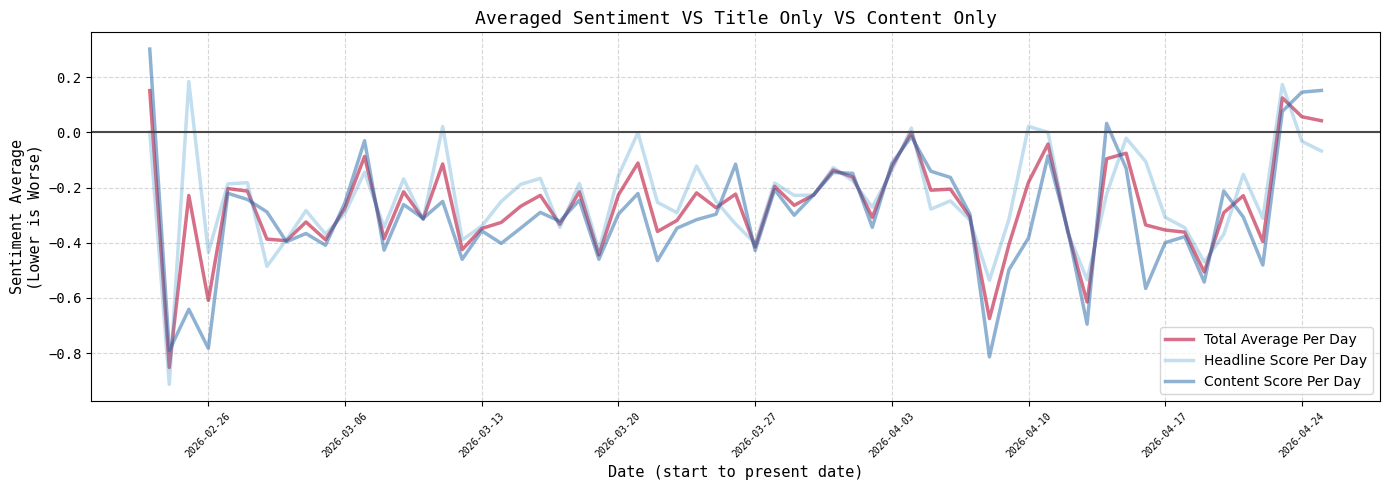

In [7]:
# Graph 1: This is a line graph comparing the sentiment scores if we use titles alone, content alone, or the average of them.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(sentiment_by_day_for_avg['date'], sentiment_by_day_for_avg['mean'], color='#BC1139', linewidth=2.5, label='Total Average Per Day',alpha=0.6)
ax1.plot(sentiment_by_day_for_title['date'], sentiment_by_day_for_title['mean'], color='#3594cc', linewidth=2.5, label='Headline Score Per Day',alpha=0.3)
ax1.plot(sentiment_by_day_for_content['date'], sentiment_by_day_for_content['mean'], color='#2066a8', linewidth=2.5, label='Content Score Per Day',alpha=0.5)

ax1.set_ylabel('Sentiment Average\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.legend(loc='lower right')
ax1.axhline(0, color="#4D4848")
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
plt.xticks(rotation=45, fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)

# plt.text(sentiment_by_day_for_avg['date'].iloc[1], -0.93, '<-- Diplomacy fails with\n    talks breaking down',
#          color="#000000", fontsize=10, fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[5], -0.24, '<-- War begings with\n    joint strikes on Iran'
#          , color="#000000",fontsize=10,fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[8], -0.37, '<-- Iran closes Strait\n     of Hormuz',
#          color="#000000", fontsize=10, fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[18], -0.20, 'Trump postpones Iran strikes -->\nand talks announced',
#          color="#000000", fontsize=10, fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[38], 0.02, 'Ceasefire announced -->',
#          color="#000000", fontsize=10, fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[41], -0.7, 'US blockade begins  -->',
#          color="#000000", fontsize=10, fontfamily='monospace')

# plt.text(sentiment_by_day_for_avg['date'].iloc[51], -0.12, '<-- Iran declares Strait\n    of Hormuz open',
#          color="#000000", fontsize=10, fontfamily='monospace')

plt.title('Averaged Sentiment VS Title Only VS Content Only', fontsize=13, fontfamily='monospace')
plt.tight_layout()
plt.savefig('../Outputs/Graphs/Sentiments.png', dpi=300, bbox_inches='tight')
plt.show()

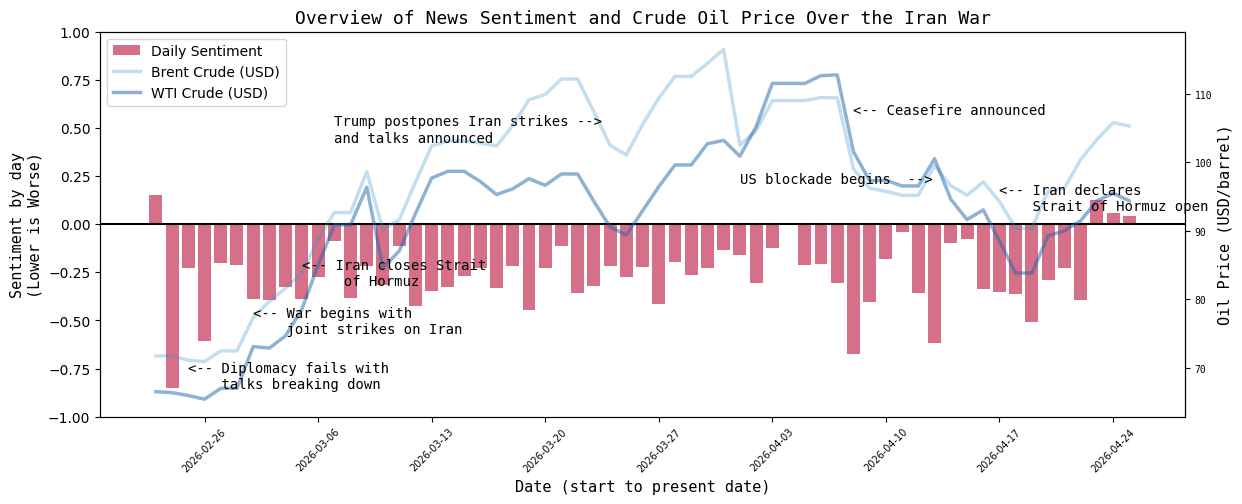

In [8]:
# Graph 2: Overview of oil and sentiment.

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.bar(All_needed_data['date'], All_needed_data['sentiment_mean'], color='#BC1139', width=0.8, label='Daily Sentiment',alpha=0.6)
ax1.axhline(0, color='black')
ax1.set_ylabel('Sentiment by day\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.set_ylim(-1, 1)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['brent'], color='#3594cc', linewidth=2.5, label='Brent Crude (USD)',alpha=0.3)
ax2.plot(All_needed_data['date'], All_needed_data['wti'], color='#2066a8', linewidth=2.5, label='WTI Crude (USD)',alpha=0.5)
ax2.set_ylabel('Oil Price (USD/barrel)', fontsize=11, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.text(sentiment_by_day_for_avg['date'].iloc[2], 67, '<-- Diplomacy fails with\n    talks breaking down',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[6], 75, '<-- War begins with\n    joint strikes on Iran'
         , color="#000000",fontsize=10,fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[9], 82, '<-- Iran closes Strait\n     of Hormuz',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[11], 103, 'Trump postpones Iran strikes -->\nand talks announced',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[43], 107, '<-- Ceasefire announced',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[36], 97, 'US blockade begins  -->',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[52], 93, '<-- Iran declares\n    Strait of Hormuz open',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.title('Overview of News Sentiment and Crude Oil Price Over the Iran War', fontsize=13, fontfamily='monospace')
plt.savefig('../Outputs/Graphs/Overview.png', dpi=300, bbox_inches='tight')
plt.show()



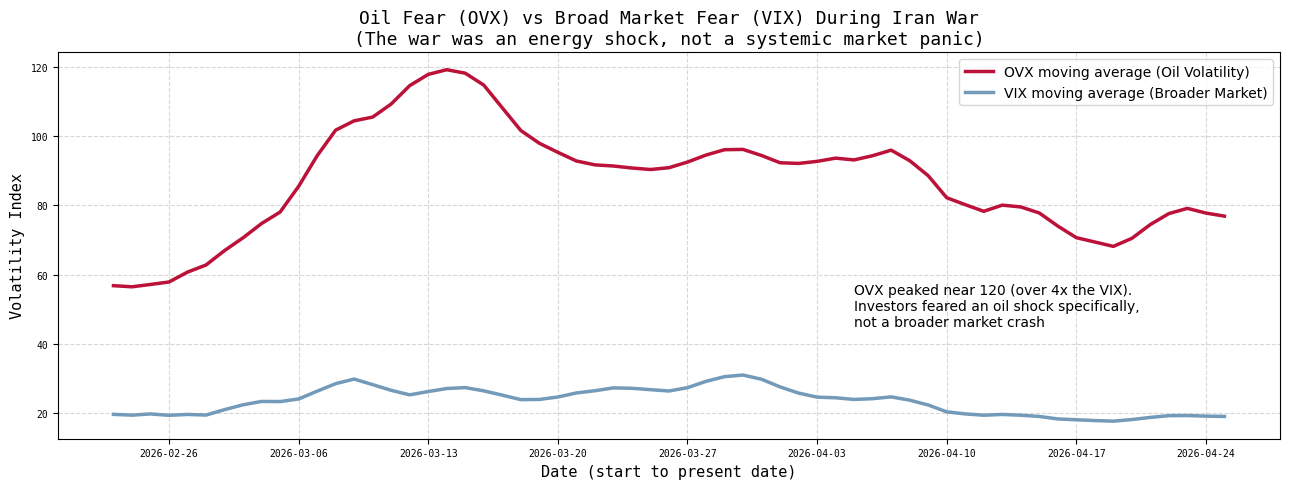

In [9]:
# Graph 3: Comparing oil volatility vs more general market fear.

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(All_needed_data['date'], All_needed_data['ovx_moving_average'], color='#BC1139', linewidth=2.5, label='OVX moving average (Oil Volatility)')
ax.plot(All_needed_data['date'], All_needed_data['vix_moving_average'], color='#739ab9', linewidth=2.5 , label='VIX moving average (Broader Market)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
ax.set_ylabel('Volatility Index',fontfamily='monospace',fontsize=11)
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)


plt.text(All_needed_data['date'].iloc[40], 45, 'OVX peaked near 120 (over 4x the VIX).\nInvestors feared an oil shock specifically,\nnot a broader market crash')

plt.grid(linestyle='--', alpha=0.5)
ax.set_title('Oil Fear (OVX) vs Broad Market Fear (VIX) During Iran War\n''(The war was an energy shock, not a systemic market panic)',fontsize=13
             ,fontfamily='monospace')
ax.legend()
plt.tight_layout()

plt.savefig('../Outputs/Graphs/OVX_vs_VIX.png', dpi=300, bbox_inches='tight')
plt.show()

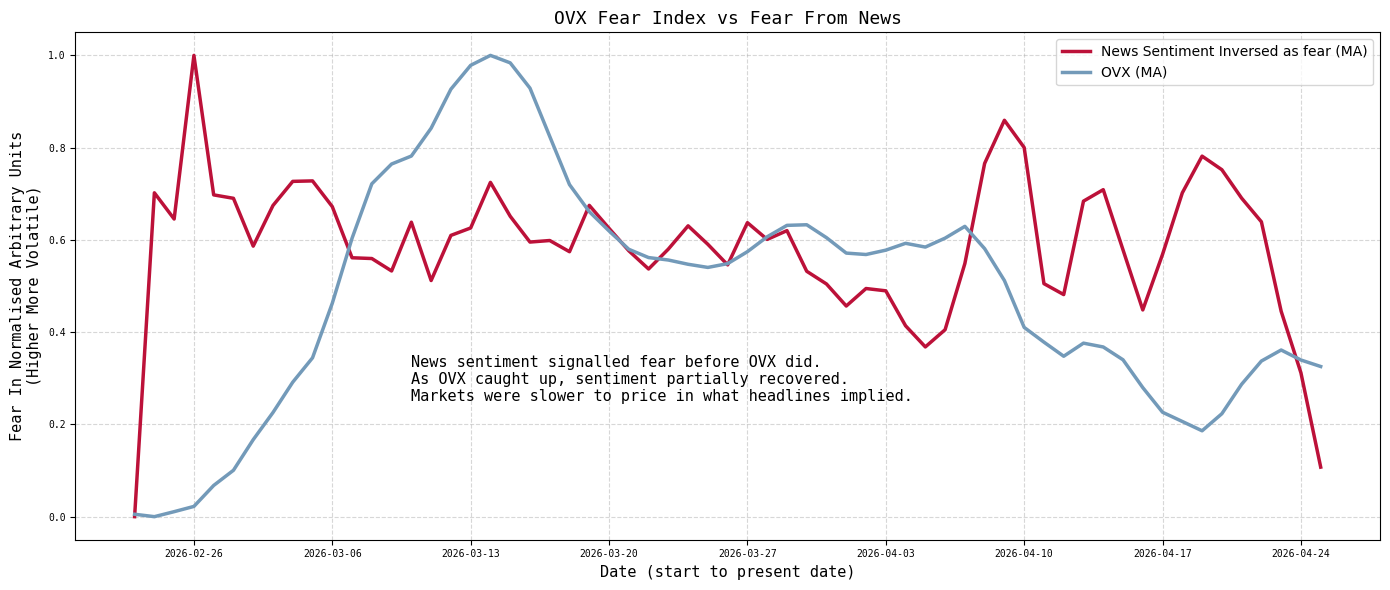

In [10]:
# Graph 4: We compare the OVX index against our measure of fear.

fig, ax = plt.subplots(figsize=(14, 6))

minmax = All_needed_data[['sentiment_mean_moving_average_inversed','ovx_moving_average']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(minmax.to_numpy())
scaled_data = pd.DataFrame(scaled_data, columns=['scaled_sentiment_mean_moving_average_inversed','scaled_ovx_moving_average'])

ax.plot(All_needed_data['date'], scaled_data['scaled_sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Inversed as fear (MA)')
ax.set_ylabel('Fear In Normalised Arbitrary Units\n(Higher More Volatile)', fontsize=11, fontfamily='monospace')
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax.plot(All_needed_data['date'], scaled_data['scaled_ovx_moving_average'], color='#739ab9', linewidth=2.5, label='OVX (MA)')

ax.legend()


plt.text(All_needed_data['date'].iloc[14], 0.25, f'News sentiment signalled fear before OVX did.\nAs OVX caught up, sentiment partially recovered.\nMarkets were slower to price in what headlines implied.'
         , color="#000000",fontsize=11,fontfamily='monospace')

plt.title('OVX Fear Index vs Fear From News', fontsize=13, fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../Outputs/Graphs/OVX_vs_news_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()


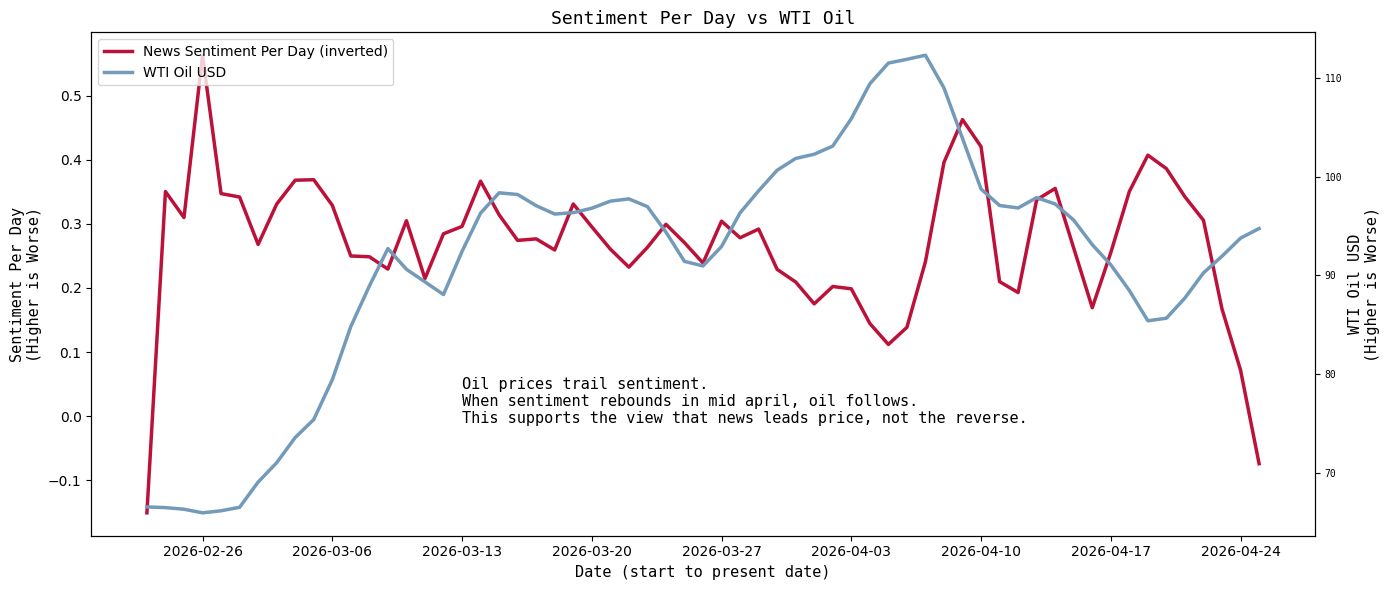

In [11]:
# Graph 5: Exploring sentiment vs lagged WTI oil.

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(All_needed_data['date'], All_needed_data['sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Per Day (inverted)')
ax1.set_ylabel('Sentiment Per Day\n(Higher is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['wti_moving_average'], color='#739ab9', linewidth=2.5, label='WTI Oil USD')
ax2.set_ylabel('WTI Oil USD\n(Higher is Worse)', fontsize=11, fontfamily='monospace')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

plt.text(All_needed_data['date'].iloc[17], 75, 'Oil prices trail sentiment.\nWhen sentiment rebounds in mid april, oil follows.\nThis supports the view that news leads price, not the reverse.'
         , color="#000000",fontsize=11,fontfamily='monospace')


plt.title('Sentiment Per Day vs WTI Oil', fontsize=13, fontfamily='monospace')
plt.tight_layout()

plt.savefig('../Outputs/Graphs/Sentiment_vs_wti.png', dpi=300, bbox_inches='tight')
plt.show()
